In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

In [61]:
data_raw_path = '../data/raw/'
images_path = 'images/image_train/'
dest_path = './data/'

product_dict = {
    2583: "pool accessories",
    1560: "home furnishings and decoration",
    1300: "model making",
    2060: "home accessories and decorations",
    2522: "stationery",
    1280: "children's toys",
    2403: "literature series",
    2280: "non-fiction books",
    1920: "textile accessories and decorations",
    1160: "trading card games",
    1320: "nursery products",
    10: "foreign literature",
    2705: "historical literature",
    1140: "figurines",
    2582: "garden accessories and decorations",
    40: "video games",
    2585: "gardening accessories and tools",
    1302: "outdoor accessories",
    1281: "children's games",
    50: "gaming accessories",
    2462: "sets of gaming or video game accessories",
    2905: "downloadable video games",
    60: "video game consoles",
    2220: "pet accessories",
    1301: "articles for newborns and babies",
    1940: "food",
    1180: "figurines to paint and assemble"
}

In [54]:
X_train = pd.read_csv(data_raw_path+'/X_train_update.csv', index_col=0)

X_train['designation'] = X_train['designation'].fillna('')
X_train['description'] = X_train['description'].fillna('')
X_train['text'] = X_train['designation'] + ' ' + X_train['description']
X_train['image_path'] = X_train.apply(lambda row: f"image_{row['imageid']}_product_{row['productid']}.jpg", axis=1)

In [55]:
Y_train = pd.read_csv(data_raw_path+'/Y_train_CVw08PX.csv', index_col=0)
Y_train['prdtypecode'] = Y_train['prdtypecode'].map(product_dict)

In [56]:
dataset = X_train.join(Y_train, how='inner')[['text', 'image_path', 'prdtypecode']]
dataset.info()
dataset.head()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         84916 non-null  object
 1   image_path   84916 non-null  object
 2   prdtypecode  84916 non-null  object
dtypes: object(3)
memory usage: 4.6+ MB


,text,image_path,prdtypecode
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,image_1263597046_product_3804725264.jpg,foreign literature
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,image_1008141237_product_436067568.jpg,non-fiction books
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,image_938777978_product_201115110.jpg,gaming accessories
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,image_457047496_product_50418756.jpg,children's toys
4,La Guerre Des Tuques Luc a des id&eacute;es de...,image_1077757786_product_278535884.jpg,historical literature


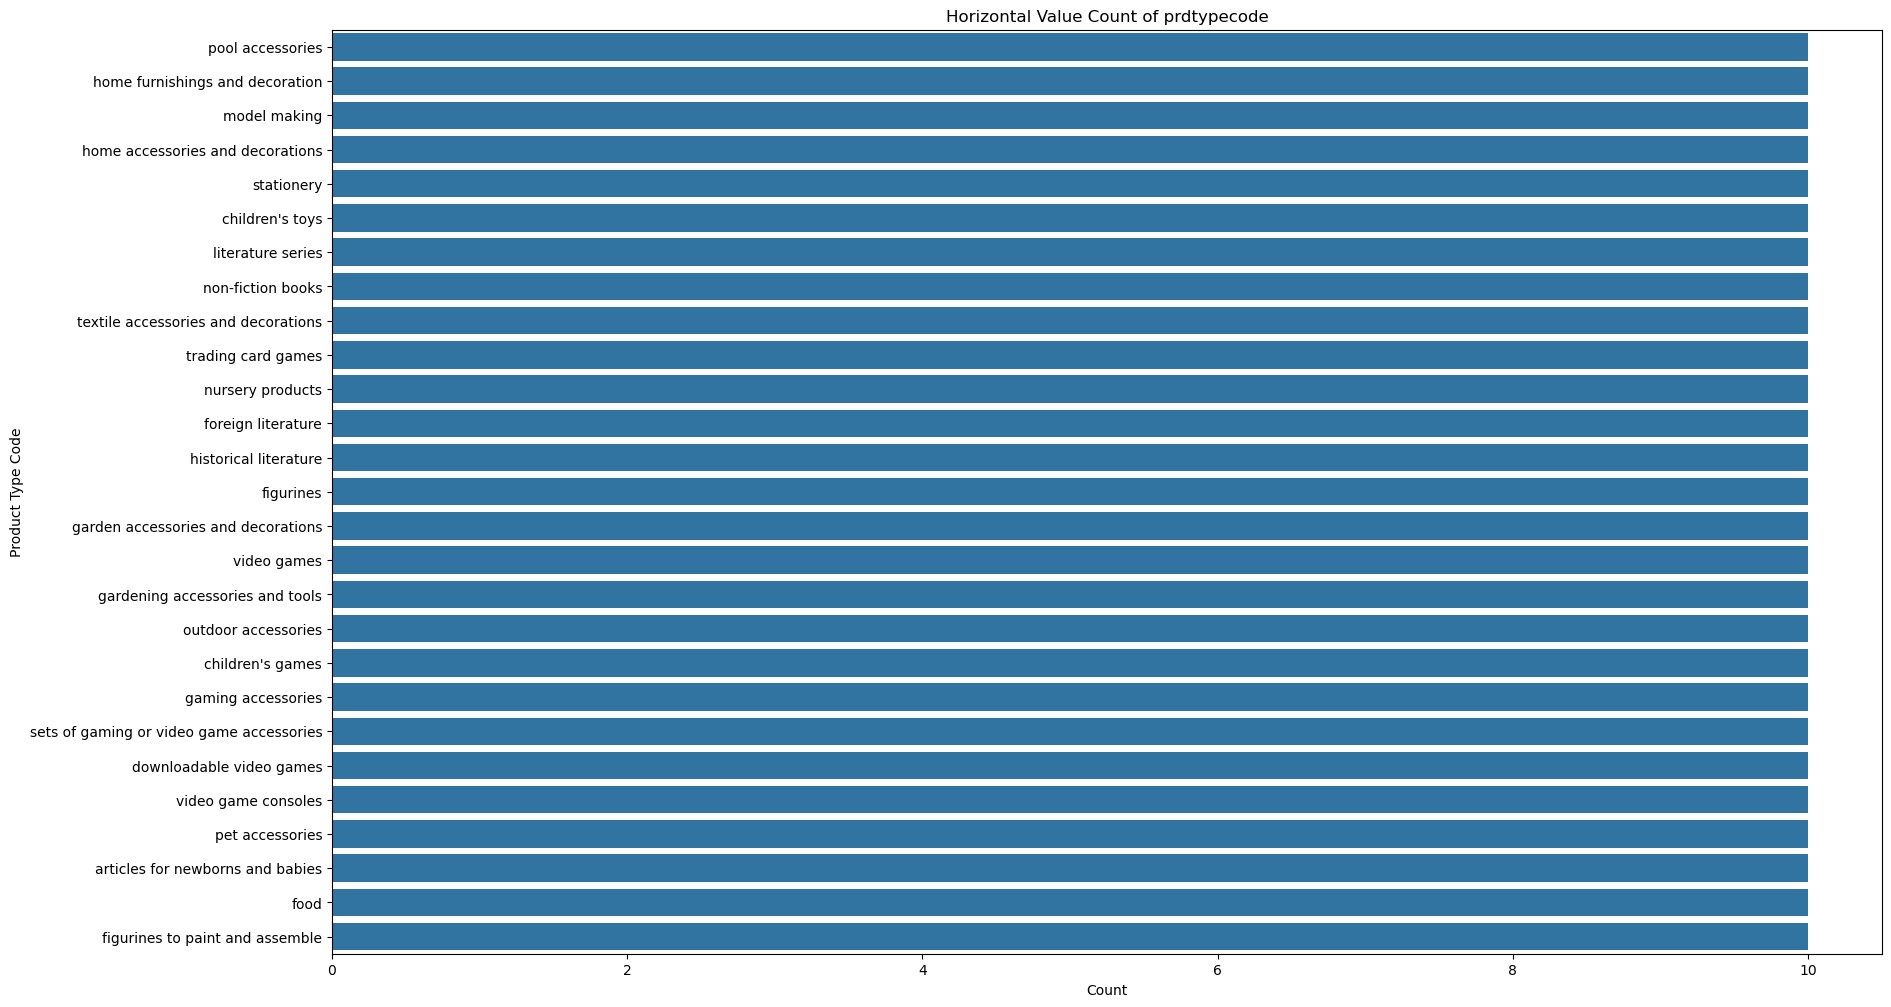

In [57]:
threshold_value = 10
dataset_reduced = pd.DataFrame()

for productid in product_dict.values():
    product_rows = dataset[dataset['prdtypecode'] == productid]
    if len(product_rows) > threshold_value:
        product_rows = product_rows.sample(n=threshold_value)
    dataset_reduced = pd.concat([dataset_reduced, product_rows])

dataset_reduced.reset_index(drop=True, inplace=True)

plt.figure(figsize=(20, 12))
sns.countplot(y='prdtypecode', data=dataset_reduced)

plt.title('Horizontal Value Count of prdtypecode')
plt.xlabel('Count')
plt.ylabel('Product Type Code')

plt.show()

In [64]:
for path in dataset_reduced['image_path']:
    source_file = data_raw_path + images_path + path
    destination_file = dest_path + path
    shutil.copy(source_file, destination_file)
dataset_reduced.to_csv(dest_path + f'dataset.csv', index=False)